# 🎭 Sentiment Analysis of User Reviews
### End-to-End NLP Pipeline — IMDb 50,000 Reviews
This notebook walks through every step: data loading → cleaning → EDA → feature engineering → model training → evaluation.

## 📦 Step 0 — Import Libraries

In [8]:
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('All libraries imported successfully!')

All libraries imported successfully!


## 📥 Step 1 — Load Dataset

In [9]:
BASE     = os.path.abspath('..')
RAW_CSV  = os.path.join(BASE, 'data', 'reviews_raw.csv')

df = pd.read_csv(RAW_CSV)
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head()

Dataset shape : (50000, 2)
Columns       : ['text', 'sentiment']


,text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative
3,This film was probably inspired by Godard's Ma...,negative
4,"Oh, brother...after hearing about this ridicul...",negative


In [10]:
print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nNull values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

Sentiment distribution:
sentiment
negative    25000
positive    25000
Name: count, dtype: int64

Null values: 0
Duplicate rows: 418


In [11]:
# Sample a positive and negative review
print('=== POSITIVE REVIEW SAMPLE ===')
print(df[df['sentiment']=='positive']['text'].iloc[0][:500])
print('\n=== NEGATIVE REVIEW SAMPLE ===')
print(df[df['sentiment']=='negative']['text'].iloc[0][:500])

=== POSITIVE REVIEW SAMPLE ===
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is 

=== NEGATIVE REVIEW SAMPLE ===
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything

## 🧹 Step 2 — Data Cleaning

In [12]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

STOP  = set(stopwords.words('english'))
lemma = WordNetLemmatizer()

print(f'Total stopwords: {len(STOP)}')
print('Sample stopwords:', list(STOP)[:15])

Total stopwords: 198
Sample stopwords: ['did', 'y', 'when', "they'd", 'here', 'how', 'whom', 'am', 'not', 'being', 'the', 'above', "wasn't", 'what', 'while']


In [13]:
# Show each cleaning step on a sample sentence
sample = 'I saw this Movie last night and it was AMAZING!! The acting was top-notch. 10/10 <br/> Would recommend!'

print('ORIGINAL :', sample)

s = sample.lower()
print('Step 1 - Lowercase        :', s)

s = re.sub(r'<[^>]+>', ' ', s)
print('Step 2 - Remove HTML      :', s)

s = re.sub(r'[^a-z\s]', ' ', s)
print('Step 3 - Remove symbols   :', s)

s = re.sub(r'\s+', ' ', s).strip()
print('Step 4 - Normalize spaces :', s)

s = ' '.join(w for w in s.split() if w not in STOP)
print('Step 5 - Remove stopwords :', s)

s = ' '.join(lemma.lemmatize(w) for w in s.split())
print('Step 6 - Lemmatize        :', s)

s = ' '.join(w for w in s.split() if len(w) > 2)
print('Step 7 - Filter short     :', s)

ORIGINAL : I saw this Movie last night and it was AMAZING!! The acting was top-notch. 10/10 <br/> Would recommend!
Step 1 - Lowercase        : i saw this movie last night and it was amazing!! the acting was top-notch. 10/10 <br/> would recommend!
Step 2 - Remove HTML      : i saw this movie last night and it was amazing!! the acting was top-notch. 10/10   would recommend!
Step 3 - Remove symbols   : i saw this movie last night and it was amazing   the acting was top notch          would recommend 
Step 4 - Normalize spaces : i saw this movie last night and it was amazing the acting was top notch would recommend
Step 5 - Remove stopwords : saw movie last night amazing acting top notch would recommend
Step 6 - Lemmatize        : saw movie last night amazing acting top notch would recommend
Step 7 - Filter short     : saw movie last night amazing acting top notch would recommend


In [14]:
def clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemma.lemmatize(w) for w in text.split() if w not in STOP and len(w) > 2]
    return ' '.join(tokens)

tqdm.pandas(desc='Cleaning')
df['clean_text'] = df['text'].progress_apply(clean)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print('Cleaning done!')
df[['text','clean_text','sentiment','word_count']].head(3)


Cleaning: 100%|████████████████████████████████████████████████████████████████| 50000/50000 [00:43<00:00, 1148.15it/s]


Cleaning done!


,text,clean_text,sentiment,word_count
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curious yellow video store controversy ...,negative,147
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...,negative,116
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...,negative,49


In [15]:
# Before vs After comparison for 3 reviews
for i, row in df.sample(3, random_state=42).iterrows():
    print(f'--- Review {i} ({row["sentiment"].upper()}) ---')
    print(f'RAW     : {row["text"][:200]}')
    print(f'CLEANED : {row["clean_text"][:200]}')
    print()

--- Review 33553 (NEGATIVE) ---
RAW     : Forget what I said about Emeril. Rachael Ray is the most irritating personality on the Food Network AND all of television. If you've never seen 30 Minute Meals, then you cannot possibly begin to compr
CLEANED : forget said emeril rachael ray irritating personality food network television never seen minute meal cannot possibly begin comprehend unfathomably annoying really truly meant even begin boggled viewed

--- Review 9427 (NEGATIVE) ---
RAW     : Former private eye-turned-security guard ditches his latest droning job and is immediately offered a chance to return to his previous profession. His assignment: to tail a mysterious French woman newl
CLEANED : former private eye turned security guard ditch latest droning job immediately offered chance return previous profession assignment tail mysterious french woman newly arrived california apparently want

--- Review 199 (NEGATIVE) ---
RAW     : Mann photographs the Alberta Rocky Mountains in a s

## 📊 Step 3 — Exploratory Data Analysis (EDA)

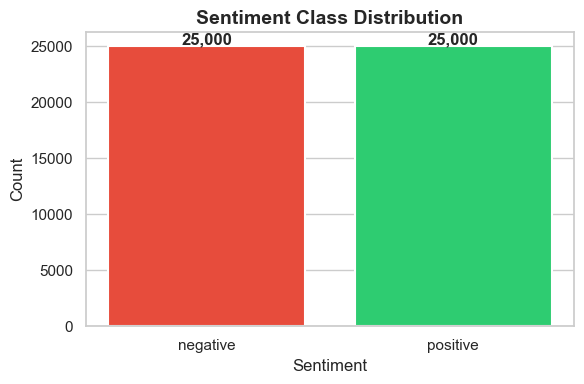

Finding: Perfectly balanced — 25,000 positive and 25,000 negative reviews.


In [16]:
# Chart 1 — Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['sentiment'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()
print('Finding: Perfectly balanced — 25,000 positive and 25,000 negative reviews.')

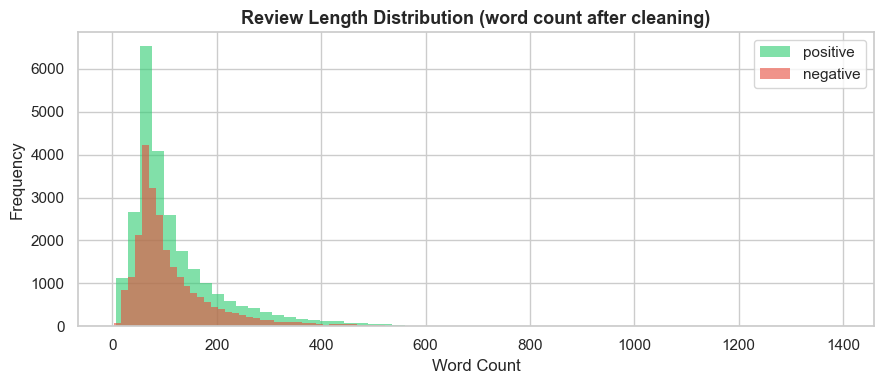

Avg word count — Positive: 118.4
Avg word count — Negative: 114.8


In [17]:
# Chart 2 — Review Length Distribution
fig, ax = plt.subplots(figsize=(9, 4))
for sent, color in [('positive','#2ecc71'), ('negative','#e74c3c')]:
    ax.hist(df[df['sentiment']==sent]['word_count'],
            bins=60, alpha=0.6, color=color, label=sent, edgecolor='none')
ax.set_title('Review Length Distribution (word count after cleaning)', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Avg word count — Positive: {df[df["sentiment"]=="positive"]["word_count"].mean():.1f}')
print(f'Avg word count — Negative: {df[df["sentiment"]=="negative"]["word_count"].mean():.1f}')

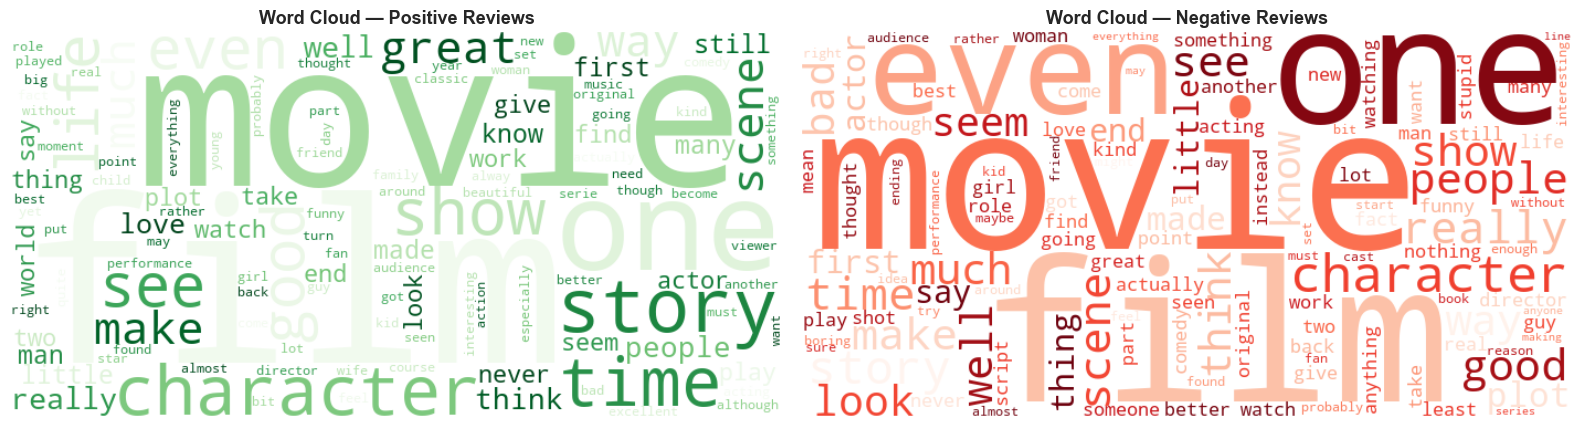

In [18]:
# Chart 3 & 4 — Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, sent, cmap in zip(axes, ['positive','negative'], ['Greens','Reds']):
    text_blob = ' '.join(df[df['sentiment']==sent]['clean_text'].sample(5000, random_state=42))
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=120).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {sent.capitalize()} Reviews', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

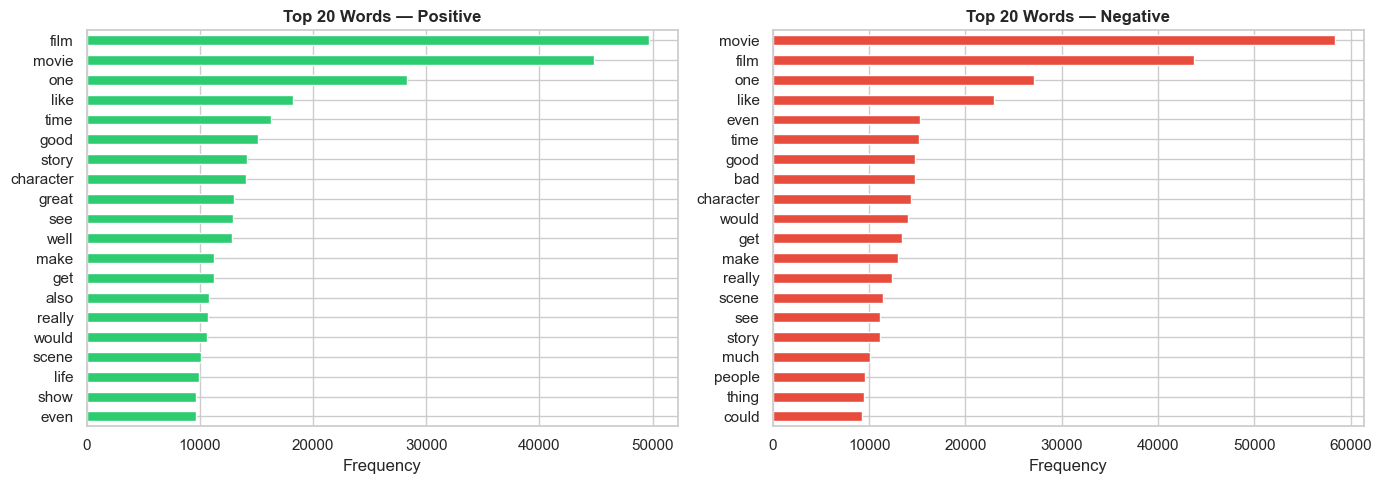

In [19]:
# Chart 5 — Top 20 Words per Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sent, color in zip(axes, ['positive','negative'], ['#2ecc71','#e74c3c']):
    cv = CountVectorizer(max_features=20)
    cv.fit_transform(df[df['sentiment']==sent]['clean_text'])
    freq = dict(zip(cv.get_feature_names_out(),
                    cv.transform(df[df['sentiment']==sent]['clean_text']).toarray().sum(axis=0)))
    pd.Series(freq).sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 20 Words — {sent.capitalize()}', fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout(); plt.show()

In [20]:
# Summary statistics
print('=== Dataset Summary ===')
print(df[['word_count']].describe().round(2))

=== Dataset Summary ===
       word_count
count     50000.0
mean        116.6
std          88.3
min           3.0
25%          62.0
50%          87.0
75%         142.0
max        1390.0


## ⚙️ Step 4 — Feature Engineering (TF-IDF)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'],
    test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'Train label balance:\n{y_train.value_counts()}')

Train size : 40,000
Test size  : 10,000
Train label balance:
sentiment
positive    20000
negative    20000
Name: count, dtype: int64


In [22]:
vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f'Train matrix shape : {X_train_vec.shape}')
print(f'Test  matrix shape : {X_test_vec.shape}')
print(f'Vocabulary size    : {len(vectorizer.vocabulary_):,}')

Train matrix shape : (40000, 50000)
Test  matrix shape : (10000, 50000)
Vocabulary size    : 50,000


In [23]:
# Show top TF-IDF terms for a sample review
sample_idx = 0
feature_names = vectorizer.get_feature_names_out()
row = X_train_vec[sample_idx]
top_idx = row.toarray()[0].argsort()[-10:][::-1]
print(f'Review: {X_train.iloc[sample_idx][:100]}')
print('\nTop 10 TF-IDF terms:')
for idx in top_idx:
    print(f'  {feature_names[idx]:<25} {row.toarray()[0][idx]:.4f}')

Review: close experience one patient probably best reason heart rushing throughout entire film intense sensi

Top 10 TF-IDF terms:
  best reason               0.2941
  one patient               0.2878
  experience one            0.2726
  rushing                   0.2622
  marvellous                0.2480
  sound track               0.2313
  sensible                  0.2306
  throughout entire         0.2253
  revealing                 0.2071
  probably best             0.2054


## 🤖 Step 5 — Model Training

In [24]:
clf = LogisticRegression(C=5, solver='lbfgs', max_iter=1000, n_jobs=-1)
clf.fit(X_train_vec, y_train)
print('Model trained!')
print(f'Classes: {clf.classes_}')

Model trained!
Classes: ['negative' 'positive']


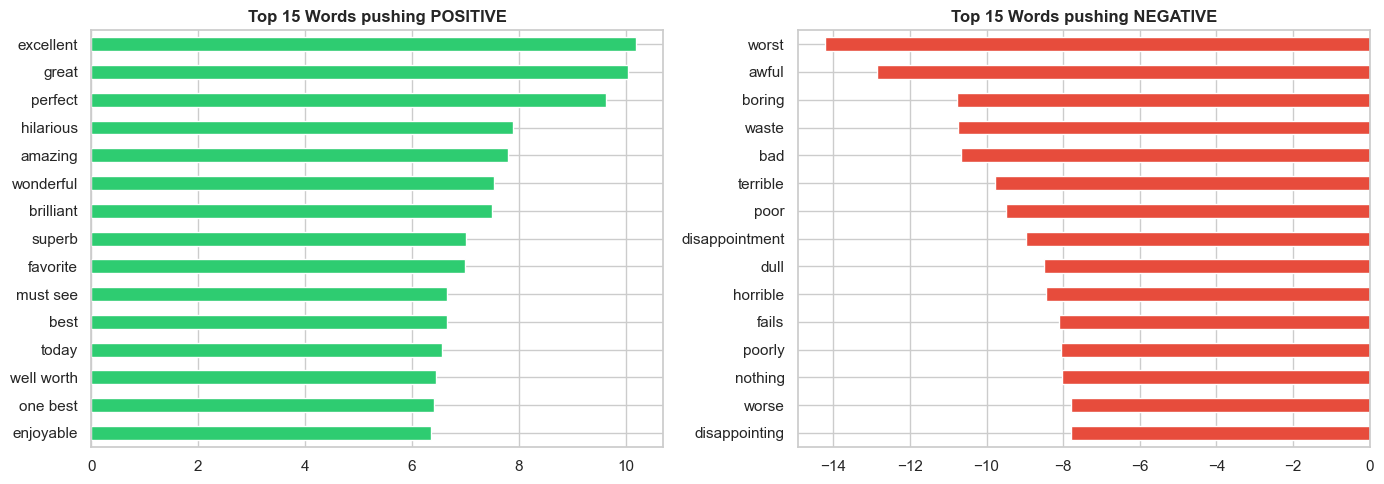

In [25]:
# Top positive and negative words learned by the model
pos_idx = list(clf.classes_).index('positive')
coef = clf.coef_[0]
top_pos = pd.Series(coef, index=feature_names).nlargest(15)
top_neg = pd.Series(coef, index=feature_names).nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos.sort_values().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 15 Words pushing POSITIVE', fontweight='bold')
top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 15 Words pushing NEGATIVE', fontweight='bold')
plt.tight_layout(); plt.show()

## 📈 Step 6 — Model Evaluation

In [26]:
y_pred  = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:, pos_idx]

report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.90      0.90      5000
    positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



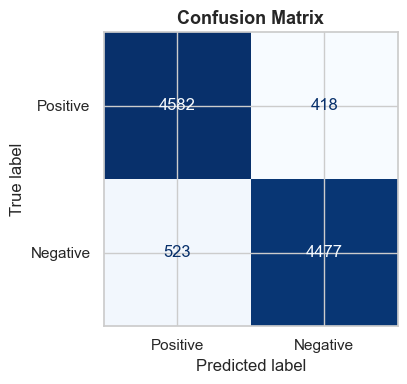

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['positive','negative'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Positive','Negative']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

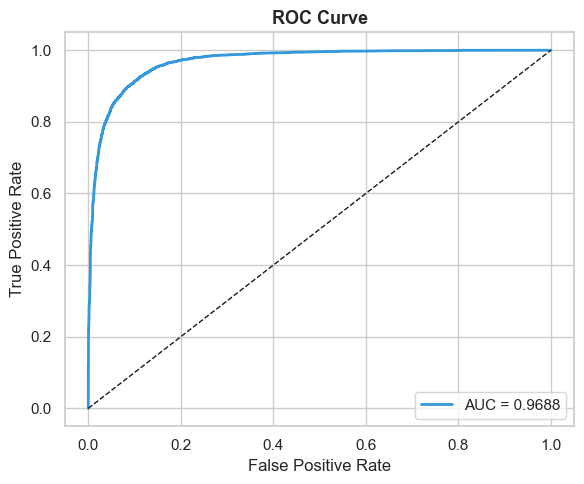

ROC-AUC Score: 0.9688


In [28]:
# ROC Curve
fpr, tpr, _ = roc_curve((y_test == 'positive').astype(int), y_proba)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print(f'ROC-AUC Score: {roc_auc:.4f}')

In [29]:
# Final metrics summary
print('=== FINAL MODEL PERFORMANCE ===')
print(f"Accuracy    : {report['accuracy']:.4f}")
print(f"F1 Positive : {report['positive']['f1-score']:.4f}")
print(f"F1 Negative : {report['negative']['f1-score']:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")

=== FINAL MODEL PERFORMANCE ===
Accuracy    : 0.9059
F1 Positive : 0.9069
F1 Negative : 0.9049
ROC-AUC     : 0.9688


## 🔮 Step 7 — Live Prediction Test

In [30]:
def predict(text):
    cleaned = clean(text)
    vec     = vectorizer.transform([cleaned])
    pred    = clf.predict(vec)[0]
    proba   = clf.predict_proba(vec)[0]
    conf    = max(proba)
    print(f'Input   : {text}')
    print(f'Cleaned : {cleaned}')
    print(f'Result  : {pred.upper()} ({conf:.1%} confidence)\n')

predict('This movie was absolutely fantastic! Best film I have seen in years.')
predict('Terrible movie. Waste of time and money. Awful acting.')
predict('It was okay, nothing special but not bad either.')

Input   : This movie was absolutely fantastic! Best film I have seen in years.
Cleaned : movie absolutely fantastic best film seen year
Result  : POSITIVE (99.2% confidence)

Input   : Terrible movie. Waste of time and money. Awful acting.
Cleaned : terrible movie waste time money awful acting
Result  : NEGATIVE (100.0% confidence)

Input   : It was okay, nothing special but not bad either.
Cleaned : okay nothing special bad either
Result  : NEGATIVE (99.8% confidence)



## 💾 Step 8 — Save Model

In [ ]:
MODEL_DIR = os.path.join(BASE, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(vectorizer, os.path.join(MODEL_DIR, 'tfidf_vectorizer.joblib'))
joblib.dump(clf,        os.path.join(MODEL_DIR, 'logistic_model.joblib'))
joblib.dump({
    'accuracy':    report['accuracy'],
    'f1_positive': report['positive']['f1-score'],
    'f1_negative': report['negative']['f1-score'],
    'roc_auc':     roc_auc,
    'train_size':  len(X_train),
    'test_size':   len(X_test),
}, os.path.join(MODEL_DIR, 'meta.joblib'))

print('Model saved to model/ folder.')
print('Run: streamlit run app.py  to launch the web interface.')